# Batch Run Comparison

Compare results across all three scenario experiments:

- **Baseline** (`batch_baseline_20260528_231106`)
- **Conservative** (`batch_conservative_20260529_000355`)
- **Optimistic** (`batch_optimistic_20260529_005521`)

Figures produced:

1. Distribution of cumulative profit — three experiments in one figure.
2. BET fleet share — one subplot per experiment.
3. BET fleet share — all three experiments combined with side-by-side boxes.


## 1 — Import libraries


In [24]:
import pathlib

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fleet_replacement.episode import EpisodeRecord

REPO_ROOT = pathlib.Path.cwd().parent

sns.set_theme(style="whitegrid")

# PGF / LaTeX font settings (mirrors analyse_batch.ipynb)
# matplotlib.rcParams.update(
#     {
#         "pgf.texsystem": "pdflatex",
#         "pgf.rcfonts": False,  # use LaTeX's own font, not matplotlib's
#         "font.family": "serif",
#         "font.serif": ["Times New Roman"],
#         "font.size": 10,
#         "axes.labelsize": 7,
#         "axes.titlesize": 8,
#         "legend.fontsize": 6,
#         "xtick.labelsize": 6,
#         "ytick.labelsize": 6,
#     }
# )

FIGURES_DIR = REPO_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
print(f"Figures dir: {FIGURES_DIR}")

Figures dir: c:\git\KTH\fleet-replacement\figures


## 2 — Load batch run data

Load all `episode_*.pkl` files from each of the three result folders.


In [25]:
IMPORTANT_DIR = REPO_ROOT / "results" / "important"

EXPERIMENTS = {
    "Baseline": IMPORTANT_DIR / "batch_baseline_20260601_010719",
    "Conservative": IMPORTANT_DIR / "batch_conservative_20260601_021136",
    "Optimistic": IMPORTANT_DIR / "batch_optimistic_20260601_032927",
    "Myopic": REPO_ROOT / "results" / "batch_env_myopic_20260608_150001",
}

# Palette — one colour per experiment (used consistently in all figures)
PALETTE = {
    "Baseline": "steelblue",
    "Conservative": "darkorange",
    "Optimistic": "seagreen",
    "Myopic": "mediumpurple",
}

# Load all episodes for every experiment
all_records: dict[str, list[EpisodeRecord]] = {}
for name, folder in EXPERIMENTS.items():
    files = sorted(folder.glob("episode_*.pkl"))
    records = [EpisodeRecord.load(str(f)) for f in files]
    all_records[name] = records
    print(
        f"{name:15s}: {len(records)} episodes  "
        f"(years {records[0].years[0]}–{records[0].years[-1]})"
    )


Baseline       : 200 episodes  (years 2026–2045)
Conservative   : 200 episodes  (years 2026–2045)
Optimistic     : 200 episodes  (years 2026–2045)
Myopic         : 1000 episodes  (years 2026–2045)


## 3 — Cumulative profit distribution (all experiments in one figure)


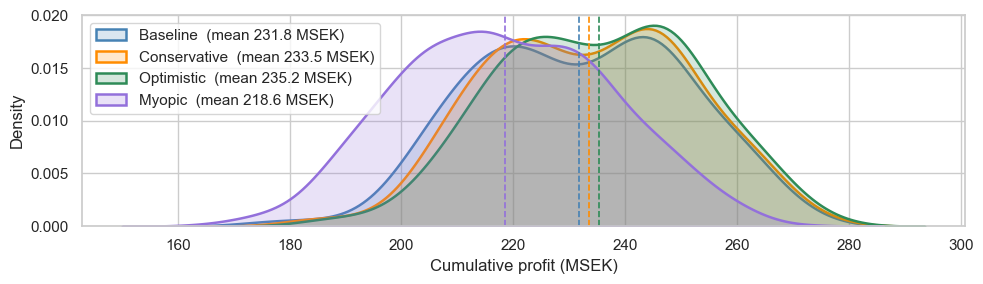

In [26]:
# fig, ax = plt.subplots(figsize=(6.48, 1.5)) # For latex 
fig, ax = plt.subplots(figsize=(10, 3))

for name, records in all_records.items():
    profits = np.array([r.total_reward for r in records]) / 1e6  # MSEK
    sns.kdeplot(
        profits,
        ax=ax,
        label=f"{name}  (mean {profits.mean():.1f} MSEK)",
        color=PALETTE[name],
        linewidth=1.8,
        fill=True,
        alpha=0.20,
    )
    ax.axvline(
        profits.mean(),
        color=PALETTE[name],
        linewidth=1.2,
        linestyle="--",
    )

ax.set_xlabel("Cumulative profit (MSEK)")
ax.set_ylabel("Density")
# ax.set_title("Distribution of cumulative profit across episodes")
ax.legend()

plt.tight_layout()
fig.savefig(FIGURES_DIR / "cumulative_profit.pgf", backend="pgf")
plt.show()

C:\Users\SIFR\AppData\Local\Temp\ipykernel_12680\2001491211.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


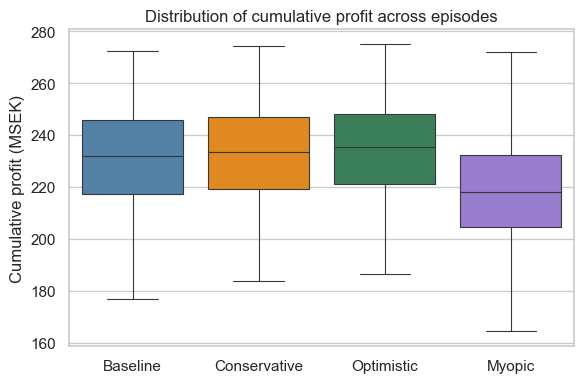

In [27]:
# Build long-form DataFrame: one row per episode
profit_df = pd.DataFrame(
    [
        {"Experiment": name, "Cumulative profit (MSEK)": r.total_reward / 1e6}
        for name, records in all_records.items()
        for r in records
    ]
)

fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=profit_df,
    x="Experiment",
    y="Cumulative profit (MSEK)",
    ax=ax,
    palette=PALETTE,
    linewidth=0.8,
    flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    order=list(EXPERIMENTS.keys()),
)

ax.set_xlabel("")
ax.set_ylabel("Cumulative profit (MSEK)")
ax.set_title("Distribution of cumulative profit across episodes")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "compare_fig1_cumulative_profit_box.pgf", backend="pgf")
plt.show()

## 4 — BET fleet share — one subplot per experiment

Each subplot mirrors the style in `analyse_batch.ipynb`.


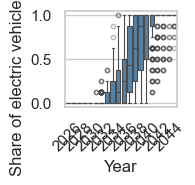

Saved: bet_share_baseline.pgf


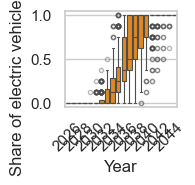

Saved: bet_share_conservative.pgf


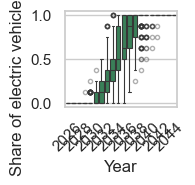

Saved: bet_share_optimistic.pgf


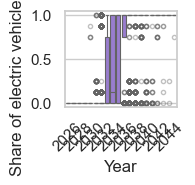

Saved: bet_share_myopic.pgf


In [28]:
for name, records in all_records.items():
    fleet_size = records[0].fleet_size
    years = records[0].years

    df = pd.DataFrame(
        [
            {"year": year, "BET share": n_elec / fleet_size}
            for r in records
            for year, n_elec in zip(r.years, r.n_electric)
        ]
    )

    fig, ax = plt.subplots(figsize=(6.48 / 3, 2.0))

    sns.boxplot(
        data=df,
        x="year",
        y="BET share",
        ax=ax,
        color=PALETTE[name],
        linewidth=0.8,
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.4},
    )

    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Year")
    ax.set_ylabel("Share of electric vehicles (BET)")
    ax.tick_params(axis="x", rotation=45)
    ax.set_xticks(ax.get_xticks()[::2])

    plt.tight_layout()
    filename = f"bet_share_{name.lower()}.pgf"
    fig.savefig(FIGURES_DIR / filename, backend="pgf", bbox_inches="tight")
    plt.show()
    print(f"Saved: {filename}")

## 5 — BET fleet share — combined figure

Three side-by-side boxes at each timestep, one colour per experiment.


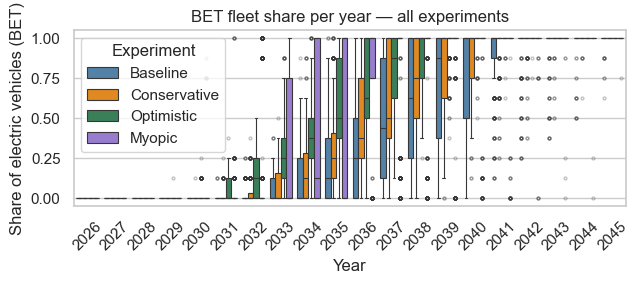

In [29]:
# Build a combined long-form DataFrame with an "Experiment" column
frames = []
for name, records in all_records.items():
    fleet_size = records[0].fleet_size
    df = pd.DataFrame(
        [
            {"year": year, "BET share": n_elec / fleet_size, "Experiment": name}
            for r in records
            for year, n_elec in zip(r.years, r.n_electric)
        ]
    )
    frames.append(df)

combined = pd.concat(frames, ignore_index=True)

fig, ax = plt.subplots(figsize=(6.48, 3))

sns.boxplot(
    data=combined,
    x="year",
    y="BET share",
    hue="Experiment",
    ax=ax,
    palette=PALETTE,
    linewidth=0.8,
    flierprops={"marker": "o", "markersize": 2, "alpha": 0.3},
)

ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Year")
ax.set_ylabel("Share of electric vehicles (BET)")
ax.set_title("BET fleet share per year — all experiments")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Experiment", loc="upper left")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "bet_share_combined.pgf", backend="pgf")
plt.show()

## 6 — Exogenous process trajectories (sanity check)

Overlay the median trajectory and 10–90 % band for each experiment.  
If the scenarios were drawn from the same distributions the bands should be statistically indistinguishable.


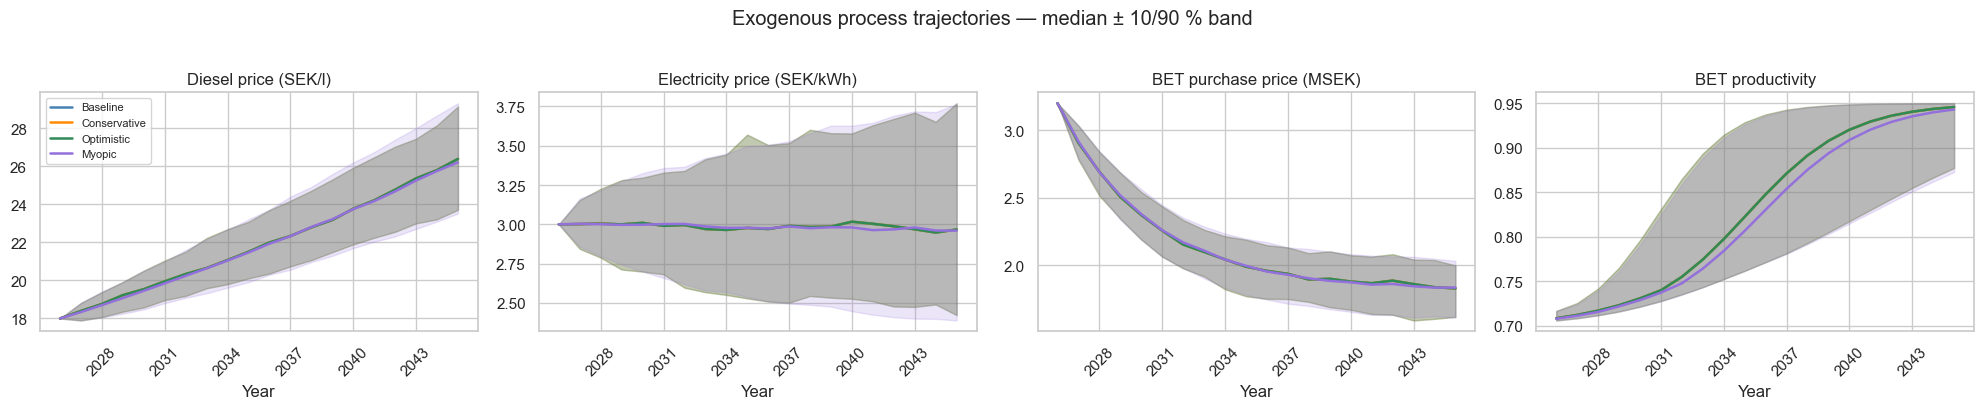

In [30]:
from matplotlib.ticker import MaxNLocator

_VARIABLES = [
    ("Diesel price (SEK/l)", lambda r: r.energy_prices_diesel),
    ("Electricity price (SEK/kWh)", lambda r: r.energy_prices_electricity),
    ("BET purchase price (MSEK)", lambda r: r.purchase_prices_BET / 1e6),
    ("BET productivity", lambda r: r.productivities_BET),
]

n_cols = len(_VARIABLES)
fig, axes = plt.subplots(1, n_cols, figsize=(5 * n_cols, 4), sharey=False)

for ax, (var_label, accessor) in zip(axes, _VARIABLES):
    for name, records in all_records.items():
        years = records[0].years
        mat = np.stack([accessor(r) for r in records])  # (n_episodes, n_steps)
        p10 = np.percentile(mat, 10, axis=0)
        p50 = np.percentile(mat, 50, axis=0)
        p90 = np.percentile(mat, 90, axis=0)

        color = PALETTE[name]
        ax.fill_between(years, p10, p90, color=color, alpha=0.18)
        ax.plot(years, p50, color=color, linewidth=1.8, label=name)

    ax.set_title(var_label)
    ax.set_xlabel("Year")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.tick_params(axis="x", rotation=45)

axes[0].legend(fontsize=8)
fig.suptitle("Exogenous process trajectories — median ± 10/90 % band", y=1.02)
plt.tight_layout()
# fig.savefig(FIGURES_DIR / "compare_fig3_info_state.pgf", backend="pgf")
plt.show()

## 7 — Top-15 % episodes: which exogenous scenarios are most profitable?

For each experiment, identify the top 15 % episodes by cumulative profit and
compare the full info-state trajectories of those high-profit episodes against
the rest. Four variables are shown: diesel price, electricity price, BET
purchase price, and BET productivity.

- **Coloured band / line** — top-15 % group (median ± IQR)
- **Grey band / line** — bottom-85 % group (median ± IQR)

A variable that consistently differs between the two groups is a strong driver
of profitability in that scenario.


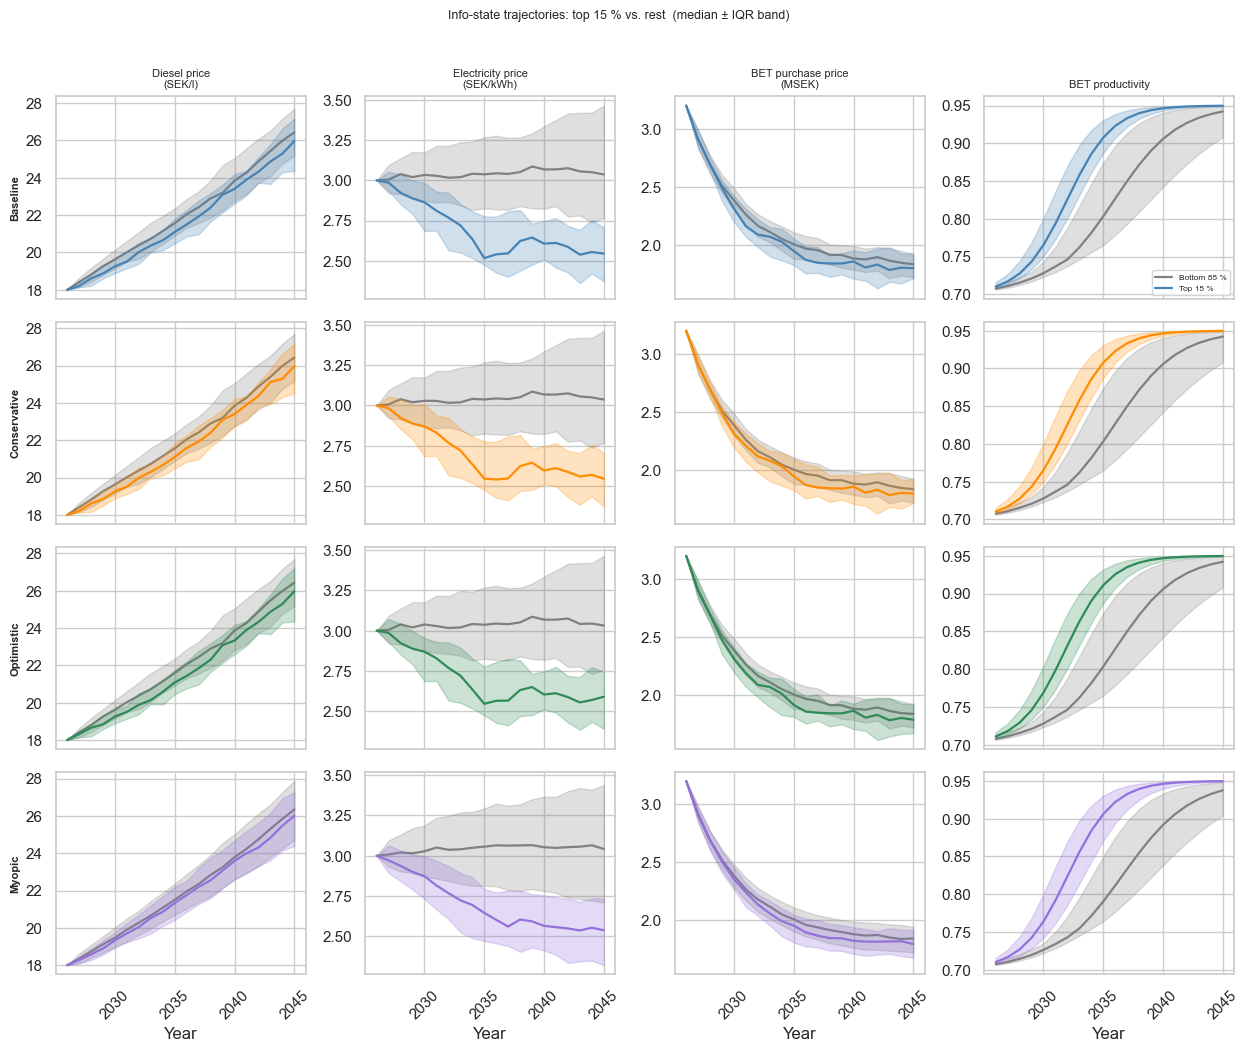

Top-15 % profit threshold per experiment:
  Baseline       : >= 252.1 MSEK  (30 episodes)
  Conservative   : >= 252.9 MSEK  (30 episodes)
  Optimistic     : >= 253.4 MSEK  (30 episodes)
  Myopic         : >= 238.8 MSEK  (150 episodes)


In [31]:
from matplotlib.ticker import MaxNLocator

TOP_FRAC = 0.15  # fraction of episodes to label "top"

_INFO_VARS = [
    ("Diesel price\n(SEK/l)",         lambda r: r.energy_prices_diesel),
    ("Electricity price\n(SEK/kWh)",  lambda r: r.energy_prices_electricity),
    ("BET purchase price\n(MSEK)",    lambda r: r.purchase_prices_BET / 1e6),
    ("BET productivity",              lambda r: r.productivities_BET),
]

n_rows = len(EXPERIMENTS)
n_cols = len(_INFO_VARS)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.2 * n_cols, 2.6 * n_rows),
    sharey="col",
    sharex="col",
)

for row_idx, (exp_name, records) in enumerate(all_records.items()):
    years = records[0].years
    color = PALETTE[exp_name]

    # Split into top-15 % and rest by cumulative profit
    profits = np.array([r.total_reward for r in records])
    threshold = np.quantile(profits, 1 - TOP_FRAC)
    top_mask = profits >= threshold

    top_records  = [r for r, m in zip(records, top_mask) if m]
    rest_records = [r for r, m in zip(records, top_mask) if not m]

    for col_idx, (var_label, accessor) in enumerate(_INFO_VARS):
        ax = axes[row_idx, col_idx]

        for group_records, group_color, group_label, zorder in [
            (rest_records, "grey",  f"Bottom {int((1 - TOP_FRAC) * 100)} %", 1),
            (top_records,  color,   f"Top {int(TOP_FRAC * 100)} %",          2),
        ]:
            mat = np.stack([accessor(r) for r in group_records])
            p25 = np.percentile(mat, 25, axis=0)
            p50 = np.percentile(mat, 50, axis=0)
            p75 = np.percentile(mat, 75, axis=0)
            ax.fill_between(years, p25, p75, color=group_color, alpha=0.25, zorder=zorder)
            ax.plot(years, p50, color=group_color, linewidth=1.6,
                    label=group_label, zorder=zorder)

        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        ax.tick_params(axis="x", rotation=45)

        if col_idx == 0:
            ax.set_ylabel(exp_name, fontsize=8, fontweight="bold")
        if row_idx == 0:
            ax.set_title(var_label, fontsize=8)
        if row_idx == n_rows - 1:
            ax.set_xlabel("Year")
        if row_idx == 0 and col_idx == n_cols - 1:
            ax.legend(fontsize=6, loc="lower right")

fig.suptitle(
    f"Info-state trajectories: top {int(TOP_FRAC * 100)} % vs. rest  "
    f"(median ± IQR band)",
    y=1.01,
    fontsize=9,
)
plt.tight_layout()
# fig.savefig(FIGURES_DIR / "top_episodes_info_state.pgf", backend="pgf", bbox_inches="tight")
plt.show()

print(f"Top-{int(TOP_FRAC * 100)} % profit threshold per experiment:")
for exp_name, records in all_records.items():
    profits = np.array([r.total_reward for r in records])
    threshold = np.quantile(profits, 1 - TOP_FRAC)
    n_top = int(np.sum(profits >= threshold))
    print(f"  {exp_name:15s}: >= {threshold / 1e6:.1f} MSEK  ({n_top} episodes)")


## 8 — Top / middle / bottom 15 % episodes

Same layout as section 7, but split into three groups: the top 15 %, the middle 70 %, and the bottom 15 % by cumulative profit. This lets you see whether the middle group tracks closer to the top or the bottom for each market variable.

- **Coloured solid line / band** — top 15 %
- **Grey solid line / band** — middle 70 %
- **Tomato dashed line / band** — bottom 15 %


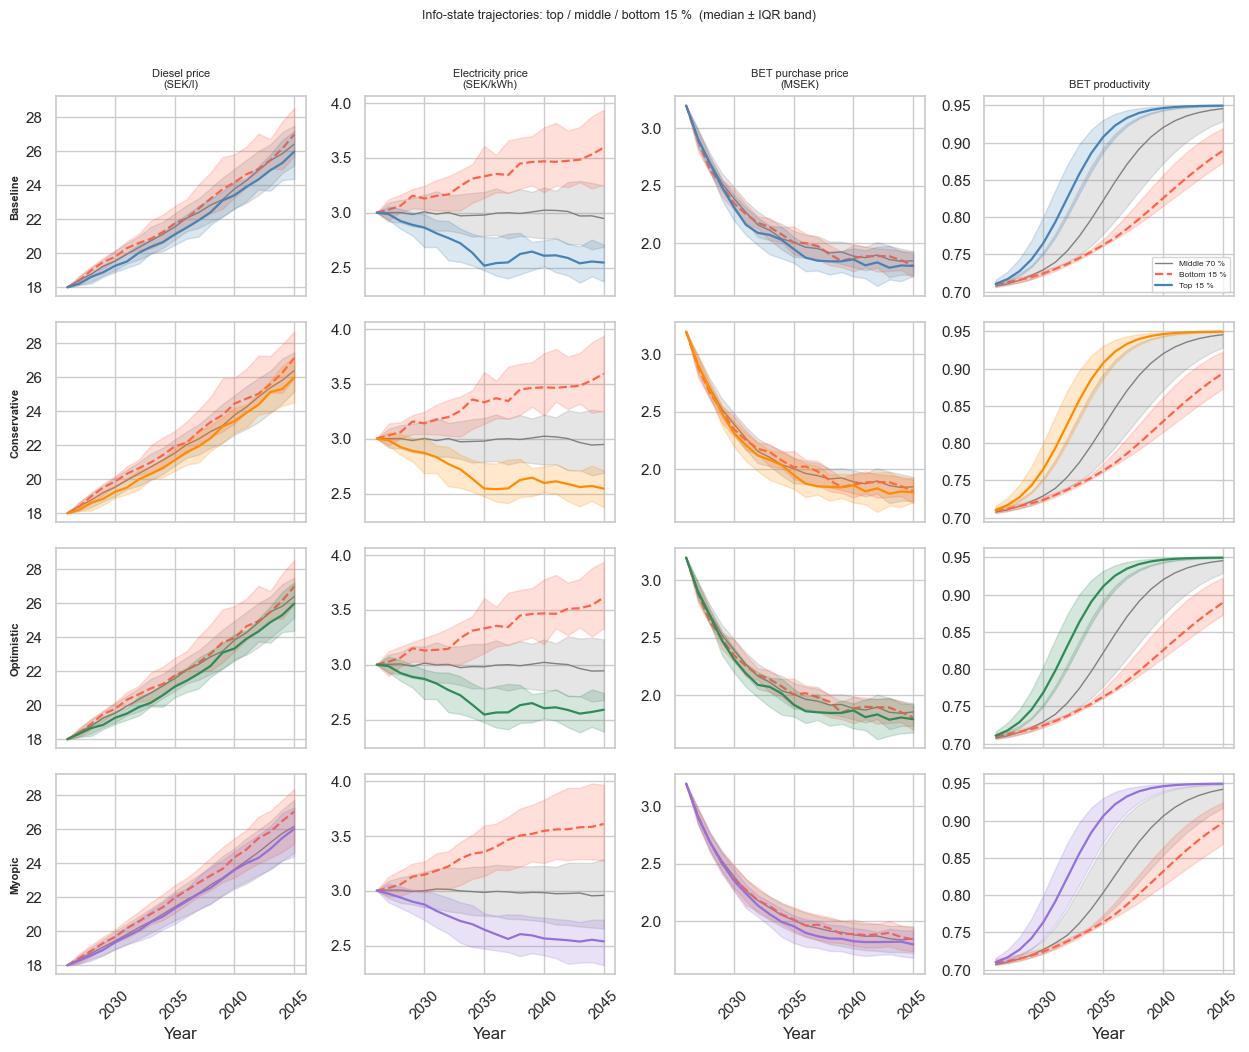

Group sizes per experiment (top / middle / bottom 15 %):
  Baseline       : top >= 252.1 MSEK (30)  |  middle (140)  |  bottom <= 211.4 MSEK (30)
  Conservative   : top >= 252.9 MSEK (30)  |  middle (140)  |  bottom <= 214.1 MSEK (30)
  Optimistic     : top >= 253.4 MSEK (30)  |  middle (140)  |  bottom <= 216.7 MSEK (30)
  Myopic         : top >= 238.8 MSEK (150)  |  middle (700)  |  bottom <= 198.2 MSEK (150)


In [32]:
TAIL_FRAC = 0.15  # symmetric tail fraction

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(3.2 * n_cols, 2.6 * n_rows),
    sharey="col",
    sharex="col",
)

for row_idx, (exp_name, records) in enumerate(all_records.items()):
    years = records[0].years
    color = PALETTE[exp_name]

    profits = np.array([r.total_reward for r in records])
    top_threshold = np.quantile(profits, 1 - TAIL_FRAC)
    bot_threshold = np.quantile(profits, TAIL_FRAC)

    top_ep  = [r for r, p in zip(records, profits) if p >= top_threshold]
    bot_ep  = [r for r, p in zip(records, profits) if p <= bot_threshold]
    mid_ep  = [r for r, p in zip(records, profits) if bot_threshold < p < top_threshold]

    for col_idx, (var_label, accessor) in enumerate(_INFO_VARS):
        ax = axes[row_idx, col_idx]

        for group_records, group_color, group_label, ls, lw, zorder in [
            (mid_ep, "grey",   f"Middle {int((1 - 2 * TAIL_FRAC) * 100)} %", "-",  1.0, 1),
            (bot_ep, "tomato", f"Bottom {int(TAIL_FRAC * 100)} %",           "--", 1.6, 2),
            (top_ep, color,    f"Top {int(TAIL_FRAC * 100)} %",              "-",  1.6, 3),
        ]:
            mat = np.stack([accessor(r) for r in group_records])
            p25 = np.percentile(mat, 25, axis=0)
            p50 = np.percentile(mat, 50, axis=0)
            p75 = np.percentile(mat, 75, axis=0)
            ax.fill_between(years, p25, p75, color=group_color, alpha=0.20, zorder=zorder)
            ax.plot(years, p50, color=group_color, linewidth=lw,
                    linestyle=ls, label=group_label, zorder=zorder)

        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
        ax.tick_params(axis="x", rotation=45)

        if col_idx == 0:
            ax.set_ylabel(exp_name, fontsize=8, fontweight="bold")
        if row_idx == 0:
            ax.set_title(var_label, fontsize=8)
        if row_idx == n_rows - 1:
            ax.set_xlabel("Year")
        if row_idx == 0 and col_idx == n_cols - 1:
            ax.legend(fontsize=6, loc="lower right")

fig.suptitle(
    f"Info-state trajectories: top / middle / bottom {int(TAIL_FRAC * 100)} %  "
    f"(median \u00b1 IQR band)",
    y=1.01,
    fontsize=9,
)
plt.tight_layout()
# fig.savefig(FIGURES_DIR / "top_vs_bottom_episodes_info_state.pgf", backend="pgf", bbox_inches="tight")
plt.show()

print(f"Group sizes per experiment (top / middle / bottom {int(TAIL_FRAC * 100)} %):")
for exp_name, records in all_records.items():
    profits = np.array([r.total_reward for r in records])
    top_thr = np.quantile(profits, 1 - TAIL_FRAC)
    bot_thr = np.quantile(profits, TAIL_FRAC)
    n_top = int(np.sum(profits >= top_thr))
    n_bot = int(np.sum(profits <= bot_thr))
    n_mid = len(records) - n_top - n_bot
    print(
        f"  {exp_name:15s}: top >= {top_thr / 1e6:.1f} MSEK ({n_top})  |  "
        f"middle ({n_mid})  |  "
        f"bottom <= {bot_thr / 1e6:.1f} MSEK ({n_bot})"
    )


## 9 — Top-15 % across experiments: which scenario assumption leads to the best outcomes?

Four subplots, one per market variable. Each subplot overlays the top-15 % episodes from all three experiments. This directly answers the question: _under which agent forecast assumption do the best-case exogenous scenarios look different?_

- Each experiment's top-15 % episodes are shown in that experiment's colour (median ± IQR band).


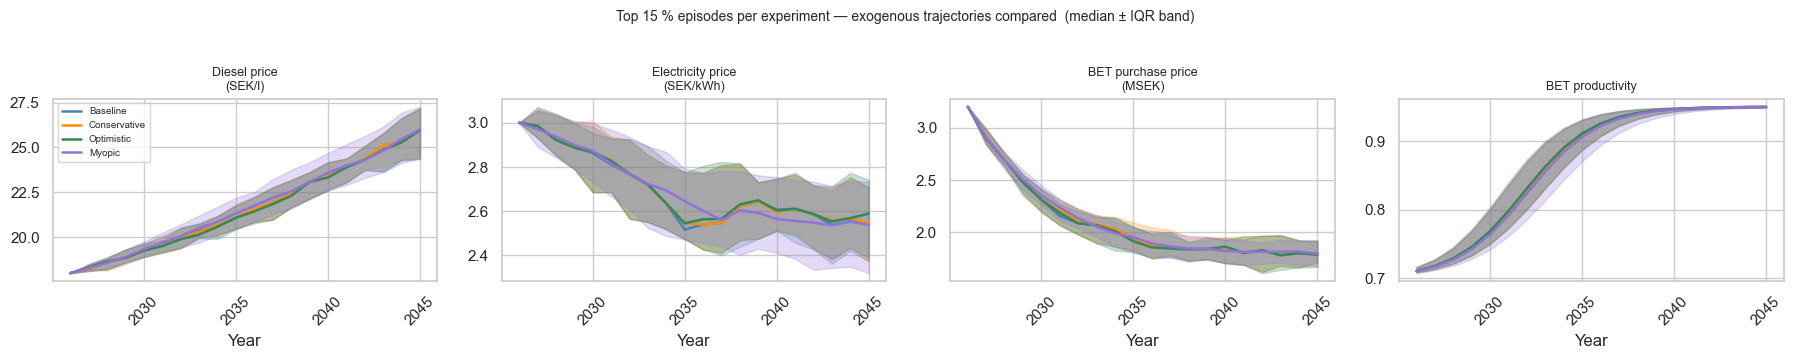

In [33]:
TOP_FRAC_CROSS = 0.15  # fraction to select as "top" within each experiment

fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 3.5), sharey=False)

for col_idx, (var_label, accessor) in enumerate(_INFO_VARS):
    ax = axes[col_idx]

    for exp_name, records in all_records.items():
        years = records[0].years
        color = PALETTE[exp_name]

        profits = np.array([r.total_reward for r in records])
        top_threshold = np.quantile(profits, 1 - TOP_FRAC_CROSS)
        top_ep = [r for r, p in zip(records, profits) if p >= top_threshold]

        mat = np.stack([accessor(r) for r in top_ep])
        p25 = np.percentile(mat, 25, axis=0)
        p50 = np.percentile(mat, 50, axis=0)
        p75 = np.percentile(mat, 75, axis=0)

        ax.fill_between(years, p25, p75, color=color, alpha=0.25)
        ax.plot(years, p50, color=color, linewidth=1.8, label=exp_name)

    ax.set_title(var_label, fontsize=9)
    ax.set_xlabel("Year")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.tick_params(axis="x", rotation=45)
    if col_idx == 0:
        ax.legend(fontsize=7)

fig.suptitle(
    f"Top {int(TOP_FRAC_CROSS * 100)} % episodes per experiment — exogenous trajectories compared  "
    f"(median \u00b1 IQR band)",
    y=1.02,
    fontsize=10,
)
plt.tight_layout()
# fig.savefig(FIGURES_DIR / "top_cross_experiment_info_state.pgf", backend="pgf", bbox_inches="tight")
plt.show()
